# Riconoscimento di animali per auto a guida autonoma

**VisionTech Solutions** vuole sviluppare un sistema di riconoscimento automatico delle immagini per distinguere tra veicoli e animali, con l'obiettivo di ottimizzare le operazioni di monitoraggio della fauna nelle aree urbane, evitando incidenti stradali e proteggendo sia gli animali che i veicoli.

VisionTech Solutions collabora con le amministrazioni comunali per implementare un sistema di monitoraggio in tempo reale nelle città, utilizzando telecamere installate lungo le strade per identificare e classificare veicoli e animali. Questo sistema aiuterà a prevenire incidenti stradali causati dall'attraversamento improvviso di animali, avvisando i guidatori tramite segnali stradali elettronici.

## Benefici:

**Automazione dei Processi:**

* Riduzione del tempo e delle risorse per monitorare manualmente le aree urbane.
* Rilevamento automatico e in tempo reale di animali e veicoli.

**Aumento della Precisione:**

* Utilizzo di una rete neurale convoluzionale (CNN) per garantire alta precisione nella classificazione delle immagini.
* Minimizzazione degli errori umani.

**Efficienza Operativa:**

* Processamento rapido e accurato di grandi volumi di dati, migliorando la risposta agli eventi.
* Maggiore sicurezza per i cittadini e riduzione dei danni ai veicoli.

**Applicazioni Multiple:**

* Sorveglianza e monitoraggio del traffico.
* Analisi del comportamento animale nelle aree urbane.
* Utilizzo dei dati per migliorare le politiche di sicurezza stradale.


## Dettagli del Progetto:

**Dataset:**

* Utilizzo del dataset CIFAR, contenente migliaia di immagini etichettate in varie categorie, inclusi veicoli e animali.

**Algoritmo:**

* Implementazione di una rete neurale convoluzionale (CNN) per l'analisi e la classificazione delle immagini.

**Output:**

* Il sistema classificherà correttamente ogni immagine come veicolo o animale.


## Valutazione del Modello:

**Accuratezza:** Proporzione di immagini classificate correttamente rispetto al totale.

**Precisione:** Qualità delle predizioni positive, indicando la proporzione di immagini correttamente identificate.


## Analisi dei Risultati:

* Identificazione di eventuali pattern di errore.
* Valutazione delle categorie di immagini confuse sistematicamente.
* Esame delle immagini errate e riflessione su possibili migliorie al modello.


## Risultato Finale:

* Presentazione completa della rete neurale convoluzionale e delle sue capacità di discriminazione tra veicoli e animali.
* Discussione dettagliata delle metriche utilizzate e un'analisi critica delle prestazioni e limitazioni del modello.


Questo progetto fornirà a VisionTech Solutions un sistema efficace per migliorare la sicurezza stradale e la gestione della fauna nelle aree urbane, dimostrando le competenze pratiche nell'applicazione del machine learning al riconoscimento delle immagini.

# Implementazione

Il progetto implementa un'analisi per **VisionTech Solutions**, al fine di automatizzare e ottimizzare la classificazione di animali e veicoli per sistemi di telerilevamento, al fine di aumentare la sicurezza per animali e umani.

## Caricamento del Dataset

Il dataset è il CIFAR10 (https://www.cs.toronto.edu/~kriz/cifar.html), che verrà utilizzato come base dati per l'addestramento della nostra rete neurale convoluzionale, come da specifiche di progetto.

Sfrutteremo i metodi di tf.Keras per caricarlo, dopodichè ne mostreremo un estratto: https://www.tensorflow.org/apidocs/python/tf/keras/datasets/cifar10/loaddata

In [1]:
# Dependencies imports

import tensorflow as tf
from matplotlib import pyplot as plt
import numpy as np

from imblearn.over_sampling import ADASYN

from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

#VGG16
from tensorflow.keras.applications import VGG16

2025-04-20 11:00:11.515341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-20 11:00:12.425463: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-20 11:00:12.495122: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-20 11:00:12.931925: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-20 11:00:17.986255: W tensorflow/compiler/tf2

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

Il dataset si compone di due split, Train e Test, suddiviso in features and target. Le nostre features sono un array numpy rappresentante un insieme di immagini 32x32 in formato RGB (3 canali). Verifichiamo la dimensione dei tensori:

In [3]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

E mostriamo un esempio di immagine e di relativa label:

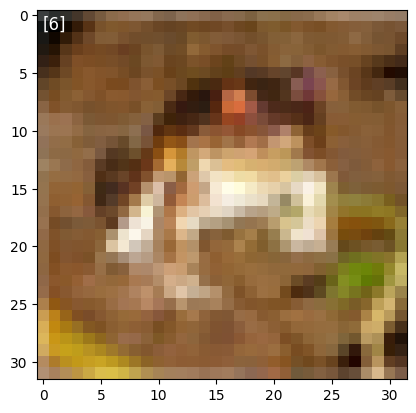

In [4]:
plt.imshow(X_train[0])
plt.text(0, 0, y_train[0], color='white', fontsize=12, verticalalignment='top', horizontalalignment='left')
plt.show()

## Tipologia e distribuzione delle labels nel dataset

Prima di cominciare con il preprocessing, verifichiamo quali sono le classi target e la relativa distribuzione:

In [5]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

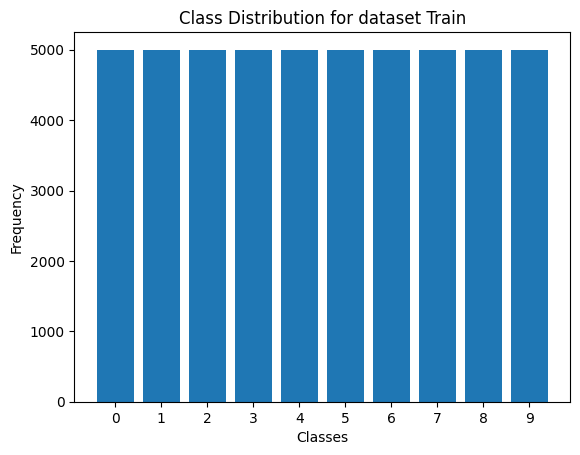

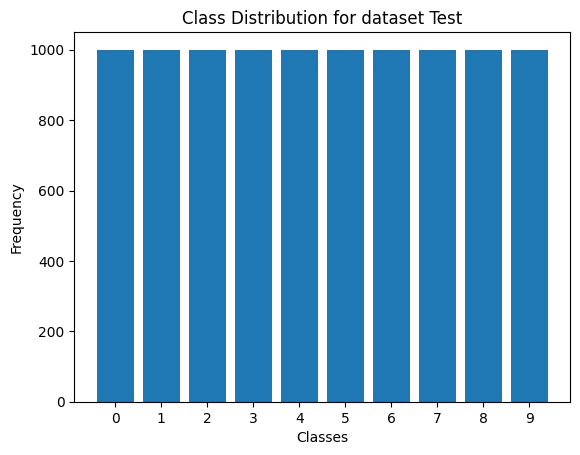

In [6]:
# Classes distributions

def print_target_distribution(dataset, dataset_name=""):
    """
    Plot distribution of classes in given dataset
    """

    unique, counts = np.unique(dataset, return_counts=True)

    plt.bar(unique, counts)
    plt.xticks(unique)
    plt.xlabel("Classes")
    plt.ylabel("Frequency")
    plt.title(f"Class Distribution for dataset {dataset_name}")
    plt.show()

print_target_distribution(y_train, "Train")
print_target_distribution(y_test, "Test")

Evinciamo che la distribuzione del target è perfettamente regolare, con la stessa frequenza per ciascuna classe.

Come mostrato nell'articolo dell'università di Toronto, e come si evince dall'istogramma sopra, il dataset possiede 10 classi, divise tra vari **veicoli** e **animali**. La richiesta del progetto è la classificazione di queste due macrocategorie, perciò ridefiniremo il problema in una **classificazione binaria**.

## Preprocessing del dataset

Effettuiamo quindi la conversione delle classi presenti in *y_train* e *y_test* e la normalizzazione dell'array delle immagini presenti in *X_train* e *X_test*

### Conversione delle classi

Cominciamo dal primo task, sostituendo le classi rispettivamente in **0** e **1**, dove 0 rappresenta un veicolo e 1 rappresenta un animale.

In [7]:
# Classes conversion in 0=Veichle and 1=Animal

veichle_class_map = [0,1,8,9]
animal_class_map = [2,3,4,5,6,7]

y_train = np.vectorize(lambda x: 0 if x in veichle_class_map else 1)(y_train)
y_test = np.vectorize(lambda x: 0 if x in veichle_class_map else 1)(y_test)

In [8]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1]), array([20000, 30000])), (array([0, 1]), array([4000, 6000])))

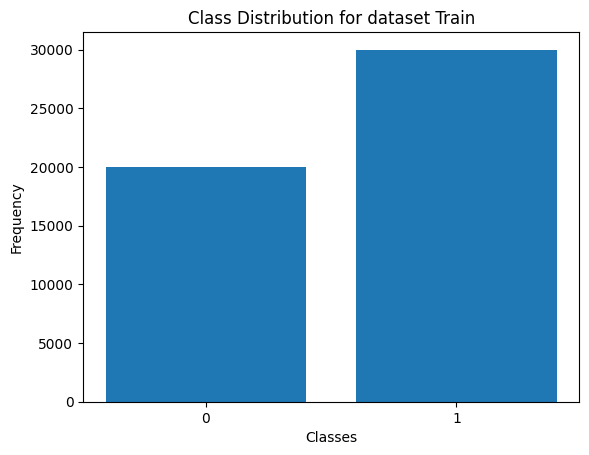

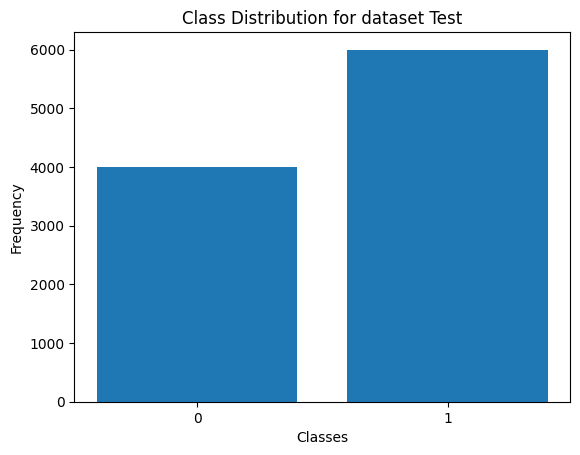

In [9]:
print_target_distribution(y_train, "Train")
print_target_distribution(y_test, "Test")

## Resampling delle classi

Notiamo subito che la conversione ha introdotto sbilanciamento tra le classi. Effettuiamo quindi un passaggio di un resampler per correggere l'anomalia e ribilanciare il tutto. In questo notebook, utilizzeremo la tecnica **ADASYN** (https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) per generare nuovi sample sintetici per la classe di minoranza **0**:

In [10]:
# Oversampling with ADASYN

def resample_dataset(resampler, X, y):
    """
    Resample dataset with ADASYN. Reshape features to 2D array, fit resampler, invert reshape and return new features.

    Args:
        resampler (ADASYN): ADASYN resampler
        X (np.array): Features
        y (np.array): Target
        is_train (bool, optional): If True, fit resampler. Defaults to False.

    Returns:
        np.array: Resampled features
    """

    #Reshaping features
    X_reshaped = X.reshape(X.shape[0], -1)

    #ADASYN Fit
    X_resampled, y_resampled = resampler.fit_resample(X_reshaped, y)

    #Inverting reshape
    X_resampled = X_resampled.reshape(X_resampled.shape[0], 32, 32, 3)

    #Returning new features
    return X_resampled, y_resampled

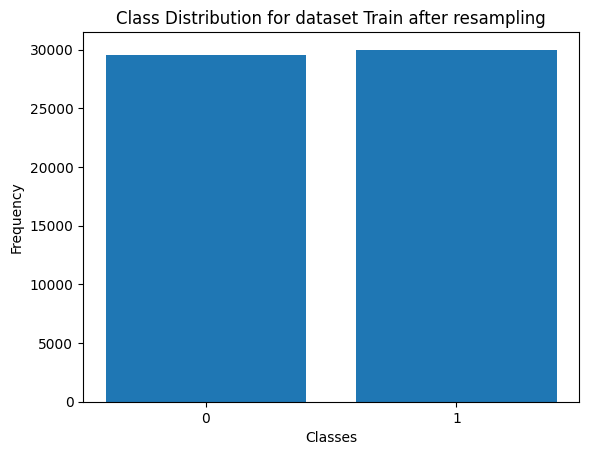

(59548, 32, 32, 3)

In [11]:
adasyn_train = ADASYN()

X_train, y_train = resample_dataset(adasyn_train, X_train, y_train)

print_target_distribution(y_train, "Train after resampling")

X_train.shape

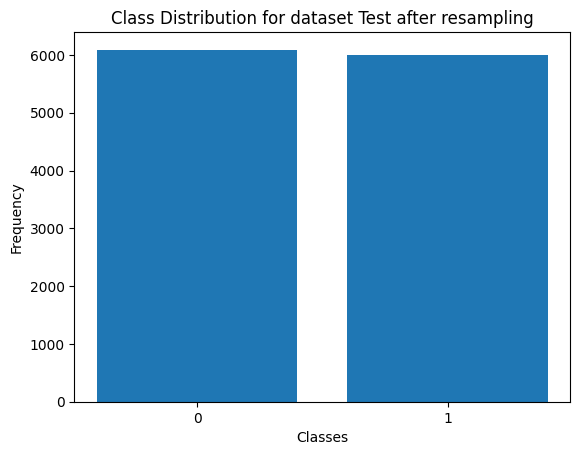

(12090, 32, 32, 3)

In [12]:
adasyn_test = ADASYN()

X_test, y_test = resample_dataset(adasyn_test, X_test, y_test)

print_target_distribution(y_test, "Test after resampling")

X_test.shape

## Preprocessing delle immagini

Ora che le classi target sono state bilanciate, applichiamo all'intero dataset la normalizzazione delle immagini sui tre canali RGB, per portare il range di dominio [0:255] in [0:1]. Ne creiamo una copia salvata poichè utilizzeremo anche la funzione preprocess_input() di VGG16 nel secondo esperimento.

In [13]:
# Images normalization

X_train_normalized = np.float32(X_train) / 255.0
X_test_normalized = np.float32(X_test) / 255.0

In [14]:
X_train_normalized.shape, X_test_normalized.shape

((59548, 32, 32, 3), (12090, 32, 32, 3))

## Definizione dell'architettura della Convolutional Neural Network

Per l'analisi di feature spaziali nelle immagini, le reti convoluzionali risultano particolarmente adatte. Come da requisiti di progetto, monteremo quindi una **CNN** effettuando differenti test per più iperparametri e più configurazioni di layers.

Effettueremo due esperimenti separati, e al termine ne confronteremo i risultati:

* Training di una CNN from-scratch, implementando manualmente i layer convoluzionali 2D, i GlobalAveragePooling e i dropout
* Effettueremo Transfer Learning dall'architettura VGG-16 (https://arxiv.org/pdf/1409.1556) sui pesi del dataset ImageNet (https://ieeexplore.ieee.org/document/5206848).

### CNN Vanilla

Iniziamo con la configurazione di una rete vanilla base:

In [15]:
tf.keras.backend.clear_session()

CNN_configs = {
    "CNN_AdamStd" : {
        "network" : Sequential([

        #InputLayer
        Input(shape=(32, 32, 3), name="InputLayer"),

        #FirstConvBlock
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), name="FirstConvLayer"),
        AveragePooling2D(pool_size=(2, 2), name="FirstPoolLayer"),
        Dropout(0.01, name="SecondDropoutLayer"),

        #SecondConvBlock
        Conv2D(64, (2, 2), activation='relu', name="SecondConvLayer"),
        GlobalAveragePooling2D("channels_last",name="SecondPoolLayer"), #Replaces Flatten() in modern CNNs


        #DenseBlock
        Dense(128, activation='relu', name="FirstDenseLayer"),
        Dense(1, activation='sigmoid', name="OutputLayer")

        ],
        name="CNN_AdamStd"),

        "optimizer" : "adam",
        "epochs" : 20,
        "history" : None
    },
    "CNN_AdamLarge" : {
        "network" : Sequential([

        #InputLayer
        Input(shape=(32, 32, 3), name="InputLayer"),

        #FirstConvBlock
        Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3), name="FirstConvLayer"),
        MaxPooling2D(pool_size=(2, 2), name="FirstPoolLayer"),

        #SecondConvBlock
        Conv2D(128, (2, 2), activation='relu', name="SecondConvLayer"),
        MaxPooling2D(name="SecondPoolLayer"),
        Dropout(0.2, name="SecondDropoutLayer"),
        Flatten(),

        #DenseBlock
        Dense(256, activation='relu', name="FirstDenseLayer"),
        Dense(1, activation='sigmoid', name="OutputLayer")

        ],
        name="CNN_AdamLarge"),

        "optimizer" : "adam",
        "epochs" : 20,
        "history" : None
    },
    "CNN_RMSProp_1layer" : {
        "network" : Sequential([

        #InputLayer
        Input(shape=(32, 32, 3), name="InputLayer"),

        #FirstConvBlock
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), name="FirstConvLayer"),
        MaxPooling2D(pool_size=(2, 2), name="FirstPoolLayer"),
        Flatten(),

        #DenseBlock
        Dense(64, activation='relu', name="FirstDenseLayer"),
        Dense(1, activation='sigmoid', name="OutputLayer")

        ],
        name="vanillaCNN_RMS_1Conv"),

        "optimizer" : "rmsprop",
        "epochs" : 20,
        "history" : None
    },
}


/home/gsadmin/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1745139893.269419  150056 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745139893.603372  150056 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745139893.603472  150056 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1745139893.607625  150056 cuda_executor

E verifichiamone pesi/gradienti e shapes per ogni layer, al fine di assicurarci che sia stata montata correttamente. Utilizzeremo anche la funzione di early stopping di Keras, per risparmiare tempo computazionale.

In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [17]:
for index, nn in enumerate(CNN_configs):

    CNN_configs[nn]["network"].summary()

    CNN_configs[nn]["network"].compile(
        optimizer=CNN_configs[nn]["optimizer"],
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    print("\n")

Model: "CNN_AdamStd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FirstConvLayer (Conv2D)         │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstPoolLayer                  │ (None, 15, 15, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondDropoutLayer (Dropout)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondConvLayer (Conv2D)        │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondPoolLayer                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstDenseLayer (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutputLayer (Dense)             │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,601 (68.75 KB)

 Trainable params: 17,601 (68.75 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "vanillaCNN_RMS_1Conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FirstConvLayer (Conv2D)         │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstPoolLayer (MaxPooling2D)   │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstDenseLayer (Dense)         │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutputLayer (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461,825 (1.76 MB)

 Trainable params: 461,825 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
for index, nn in enumerate(CNN_configs):
    print("\nBeginning training of network" + CNN_configs[nn]["network"].name)

    CNN_configs[nn]["history"] = CNN_configs[nn]["network"].fit(
        X_train_normalized,
        y_train,
        epochs=CNN_configs[nn]["epochs"],
        batch_size=32,
        validation_data=(X_test_normalized, y_test),
        callbacks=[early_stopping]
    )


Beginning training of networkCNN_AdamStd


2025-04-20 11:04:55.971144: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 731725824 exceeds 10% of free system memory.
2025-04-20 11:04:57.280207: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 731725824 exceeds 10% of free system memory.


Epoch 1/20


I0000 00:00:1745139899.173131  156481 service.cc:146] XLA service 0x7f118c005aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745139899.173484  156481 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2025-04-20 11:04:59.266414: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-20 11:04:59.677899: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  18/1861 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.5756 - loss: 0.6871

...

1861/1861 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.8054 - loss: 0.4248 - val_accuracy: 0.8625 - val_loss: 0.3277
Epoch 2/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8803 - loss: 0.2875 - val_accuracy: 0.8968 - val_loss: 0.2485
Epoch 3/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8903 - loss: 0.2631 - val_accuracy: 0.9003 - val_loss: 0.2350
Epoch 4/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8973 - loss: 0.2506 - val_accuracy: 0.9051 - val_loss: 0.2288
Epoch 5/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9002 - loss: 0.2426 - val_accuracy: 0.9098 - val_loss: 0.2226
Epoch 6/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9038 - loss: 0.2388 - val_accuracy: 0.9108 - val_loss: 0.2181
Epoch 7/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9059 - loss: 0.2338 - val_accuracy: 0.8841 - val_loss: 0.2724
Epoch 8/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9079 - loss: 0.2306 - va

2025-04-20 11:10:05.641668: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 731725824 exceeds 10% of free system memory.
2025-04-20 11:10:06.938322: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 731725824 exceeds 10% of free system memory.


Epoch 1/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.8691 - loss: 0.3012 - val_accuracy: 0.8807 - val_loss: 0.2835
Epoch 2/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9201 - loss: 0.2007 - val_accuracy: 0.9272 - val_loss: 0.1953
Epoch 3/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9356 - loss: 0.1634 - val_accuracy: 0.9355 - val_loss: 0.1606
Epoch 4/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9452 - loss: 0.1396 - val_accuracy: 0.9454 - val_loss: 0.1450
Epoch 5/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9556 - loss: 0.1135 - val_accuracy: 0.9427 - val_loss: 0.1569
Epoch 6/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9651 - loss: 0.0920 - val_accuracy: 0.9342 - val_loss: 0.1788
Epoch 7/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9708 - loss: 0.0783 - val_accuracy: 0.9385 - val_loss: 0.1755
Epoch 8/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9769 -

2025-04-20 11:15:42.392590: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 731725824 exceeds 10% of free system memory.


Epoch 1/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8228 - loss: 0.3956 - val_accuracy: 0.8837 - val_loss: 0.2767
Epoch 2/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9030 - loss: 0.2373 - val_accuracy: 0.9202 - val_loss: 0.1919
Epoch 3/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9154 - loss: 0.2112 - val_accuracy: 0.9175 - val_loss: 0.2015
Epoch 4/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9256 - loss: 0.1867 - val_accuracy: 0.9260 - val_loss: 0.1845
Epoch 5/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9331 - loss: 0.1675 - val_accuracy: 0.9280 - val_loss: 0.1896


Il maggior numero di filtri della rete **CNN_AdamStd** sembra catturare meglio le feature spaziali, restituendo un'accuracy di alcuni punti percentuale in più rispetto alle colleghe che, tra l'altro, si sono viste applicare l'early stopping alla quinta epoca:

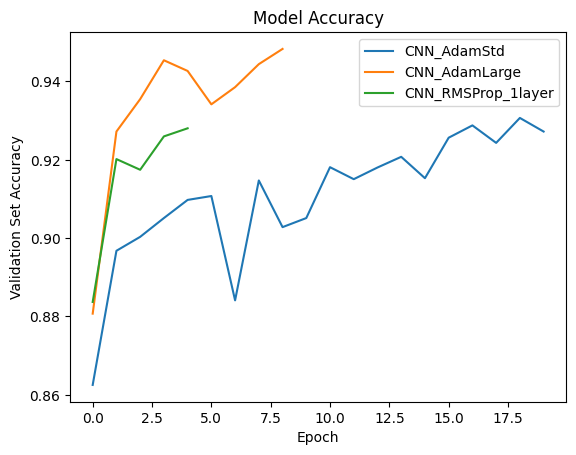

In [19]:
for hist in CNN_configs:
    plt.plot(CNN_configs[hist]["history"].history['val_accuracy'], label=hist)

plt.title('Model Accuracy')
plt.ylabel('Validation Set Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [27]:
y_pred = CNN_configs["CNN_AdamLarge"]["network"].predict(X_test_normalized)

378/378 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [31]:
y_pred = np.where(y_pred > 0.50, 1 , 0)

In [34]:
print(confusion_matrix(y_test, y_pred))

[[5678  412]
 [ 248 5752]]


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      6090
           1       0.93      0.96      0.95      6000

    accuracy                           0.95     12090
   macro avg       0.95      0.95      0.95     12090
weighted avg       0.95      0.95      0.95     12090



### Transfer Learning con VGG16

Proviamo ora, invece, ad usare i layer convoluzionali dell'architettura **VGG16**, cambiando solamente i layer densi per convertire la predizione in un task di classificazione binario.

Cominciamo con il creare il modello base:

In [20]:
# VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

In [21]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

E costruiamoci sopra il layer denso + l'output layer comune anche alle altre reti precedentemente definite con le API funzionali di tf.Keras:

In [22]:
# Transfer Learning and fine tuning

base_model_output = base_model.output
pooling = GlobalAveragePooling2D()(base_model_output)
dense = Dense(128, activation='relu')(pooling)
output = Dense(1, activation='sigmoid')(dense)
new_model = Model(inputs=base_model.input, outputs=output)

In [23]:
new_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 14,780,481 (56.38 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.applications.vgg16 import preprocess_input

X_train_vgg16 = preprocess_input(X_train)
X_test_vgg16 = preprocess_input(X_test)

In [25]:
new_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [26]:
new_model.fit(
    X_train_vgg16,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_normalized, y_test),
    callbacks=[early_stopping]
)

Epoch 1/20
1860/1861 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8350 - loss: 0.8707

2025-04-20 11:25:58.612379: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng4{} for conv (f32[512,28,2,2]{3,2,1,0}, u8[0]{0}) custom-call(f32[512,512,3,3]{3,2,1,0}, f32[28,512,2,2]{3,2,1,0}), window={size=2x2 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-04-20 11:25:58.804955: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.192748016s
Trying algorithm eng4{} for conv (f32[512,28,2,2]{3,2,1,0}, u8[0]{0}) custom-call(f32[512,512,3,3]{3,2,1,0}, f32[28,512,2,2]{3,2,1,0}), window={size=2x2 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_q

1861/1861 ━━━━━━━━━━━━━━━━━━━━ 603s 308ms/step - accuracy: 0.8350 - loss: 0.8701 - val_accuracy: 0.4963 - val_loss: 3.3260
Epoch 2/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 556s 299ms/step - accuracy: 0.9227 - loss: 0.1959 - val_accuracy: 0.4963 - val_loss: 2.4845
Epoch 3/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 555s 298ms/step - accuracy: 0.9280 - loss: 0.1831 - val_accuracy: 0.4963 - val_loss: 2.0371
Epoch 4/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 554s 298ms/step - accuracy: 0.9408 - loss: 0.1547 - val_accuracy: 0.4963 - val_loss: 4.2501
Epoch 5/20
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 555s 298ms/step - accuracy: 0.9105 - loss: 0.2852 - val_accuracy: 0.4963 - val_loss: 3.0007
